<a href="https://colab.research.google.com/github/Arjun-08/Linear-Prediction-and-LPC-Analysis/blob/main/LP%26LPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.signal import lfilter
import scipy.linalg

In [ ]:
file_path = "/content/drive/MyDrive/dataFiles/Train_0_Example_1.wav"
N_values = [5, 10, 20]  # Different values of N

In [ ]:
print(f"Loading audio file: {file_path}\n")
x, sr = librosa.load(file_path, sr=None, duration=1.0)

Loading audio file: /content/drive/MyDrive/dataFiles/Train_0_Example_1.wav



Displaying Original Signal



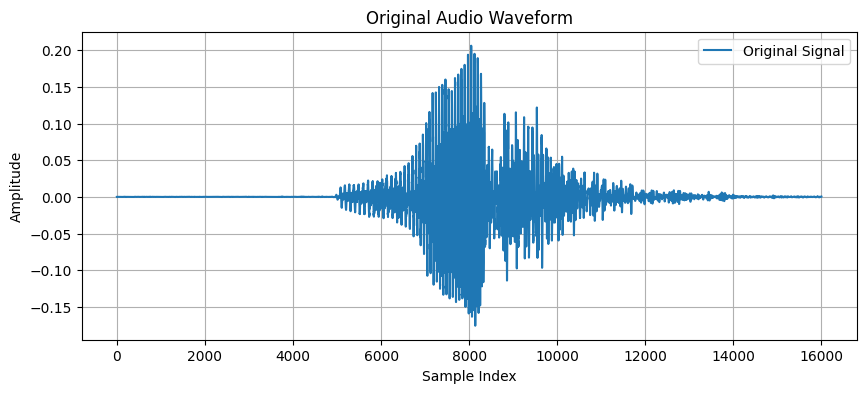

In [ ]:
plt.figure(figsize=(10, 4)) ##plot for original signal
plt.plot(x, label='Original Signal')
plt.title("Original Audio Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

In [ ]:
errors = {}
reconstructed_signals = {}
coefficients = {}
MSE_values = {}


Processing for N=5

LPC Coefficients for N=5: [ 1.         -1.2747833   0.02351156  0.25724902 -0.06778535  0.12393362]

Mean Squared Error for N=5: 2.3122696806207264e-05



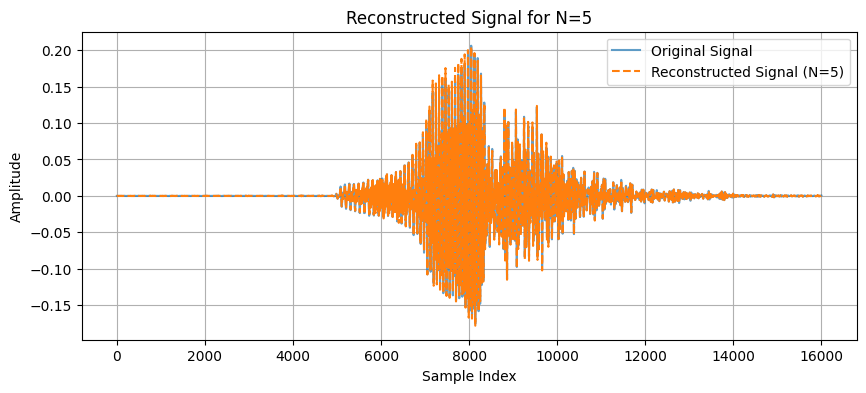

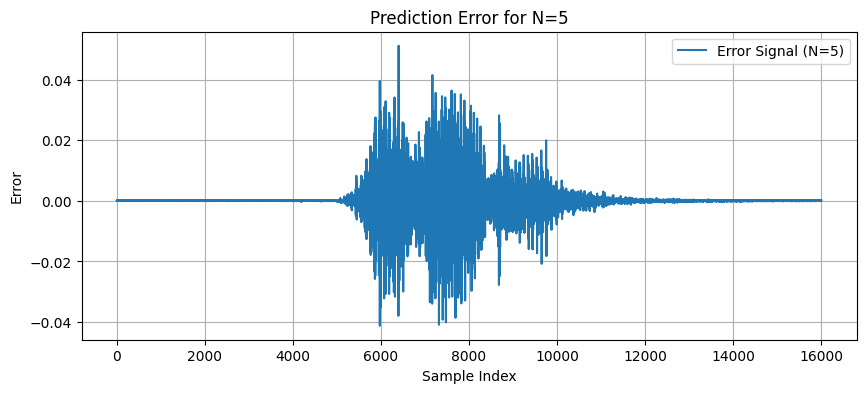


Processing for N=10

LPC Coefficients for N=10: [ 1.         -1.16801351 -0.02167157  0.2526618   0.00241519  0.01455249
 -0.13885196  0.01497161  0.06297817  0.07735635  0.01743444]

Mean Squared Error for N=10: 2.060842717301354e-05



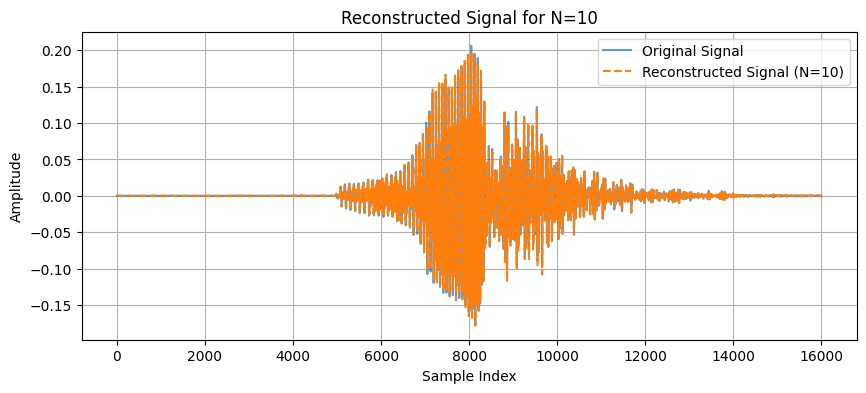

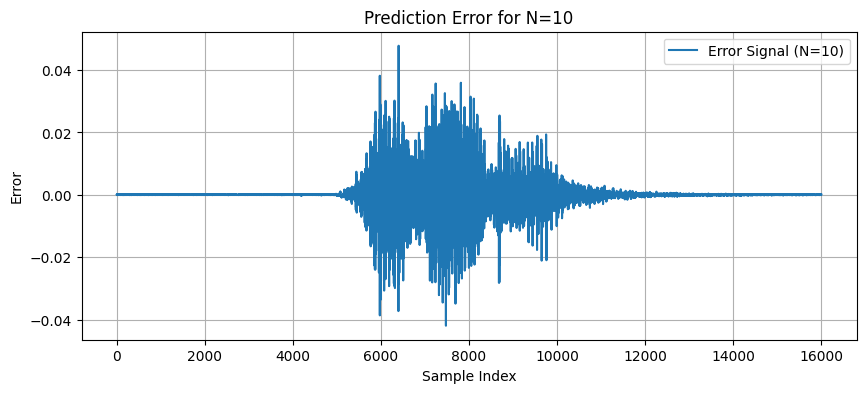


Processing for N=20

LPC Coefficients for N=20: [ 1.         -1.24674064  0.2133404   0.01763214  0.11069979  0.02343625
 -0.19564357  0.04762961  0.00962045  0.18092464 -0.20324863  0.10061156
 -0.0217334  -0.12775627  0.53903842 -0.40603081  0.29573994 -0.41209714
  0.23804212 -0.05119803 -0.01763131]

Mean Squared Error for N=20: 1.5028988645095041e-05



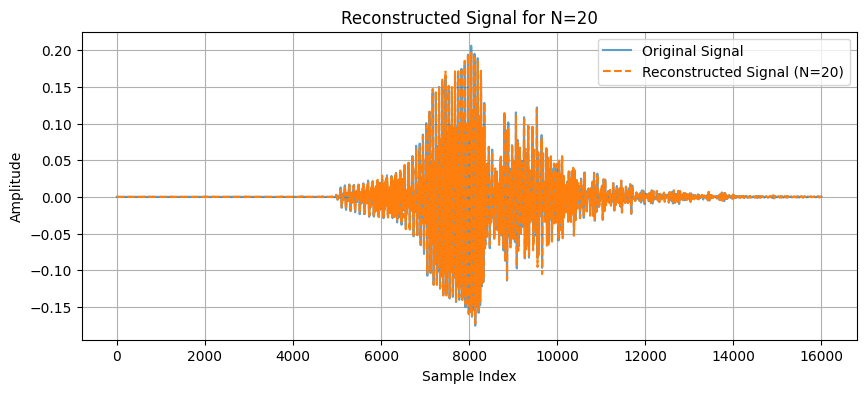

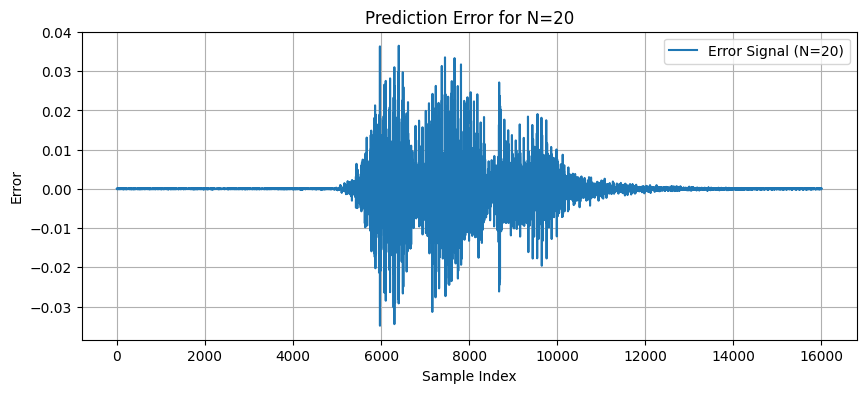

In [ ]:
for N in N_values:
    print(f"\nProcessing for N={N}\n")

    R = np.correlate(x, x, mode='full')
    R = R[len(x)-1:len(x)-1+N+1]
    a = scipy.linalg.solve_toeplitz((R[:-1], R[:-1]), -R[1:])
    a = np.insert(a, 0, 1)
    coefficients[N] = a
    print(f"LPC Coefficients for N={N}: {a}\n")

    e = lfilter(a, 1, x)
    reconstructed = x - e
    errors[N] = e
    reconstructed_signals[N] = reconstructed

    MSE = np.mean(e ** 2)
    MSE_values[N] = MSE
    print(f"Mean Squared Error for N={N}: {MSE}\n")

    plt.figure(figsize=(10, 4)) ##reconstructed signal
    plt.plot(x, label='Original Signal', alpha=0.7)
    plt.plot(reconstructed, label=f'Reconstructed Signal (N={N})', linestyle='dashed')
    plt.title(f"Reconstructed Signal for N={N}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(10, 4)) ###error signal
    plt.plot(e, label=f'Error Signal (N={N})')
    plt.title(f"Prediction Error for N={N}")
    plt.xlabel("Sample Index")
    plt.ylabel("Error")
    plt.legend()
    plt.grid()
    plt.show()

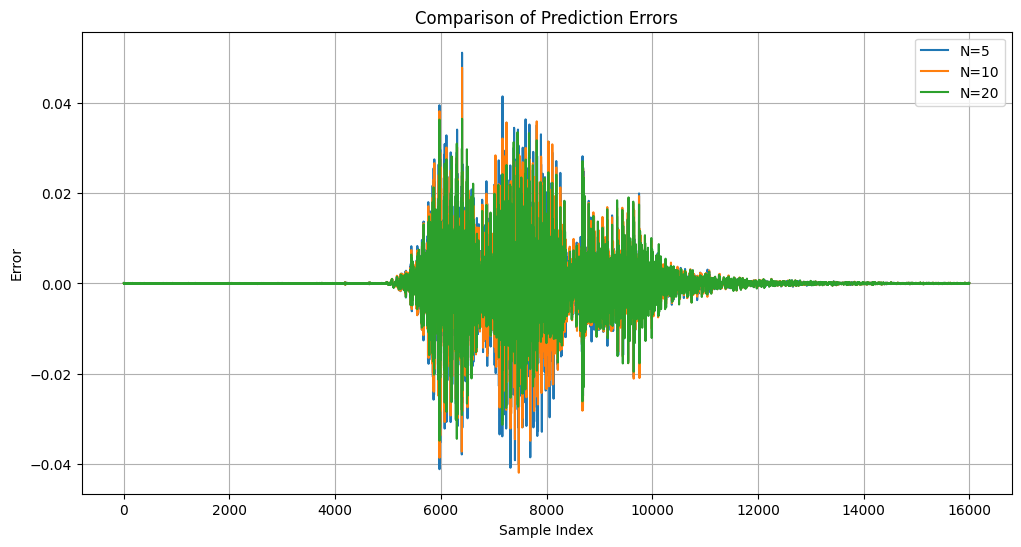

In [ ]:
plt.figure(figsize=(12, 6)) ##plot to compare prediction errors
for N in N_values:
    plt.plot(errors[N], label=f'N={N}')
plt.title("Comparison of Prediction Errors")
plt.xlabel("Sample Index")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()


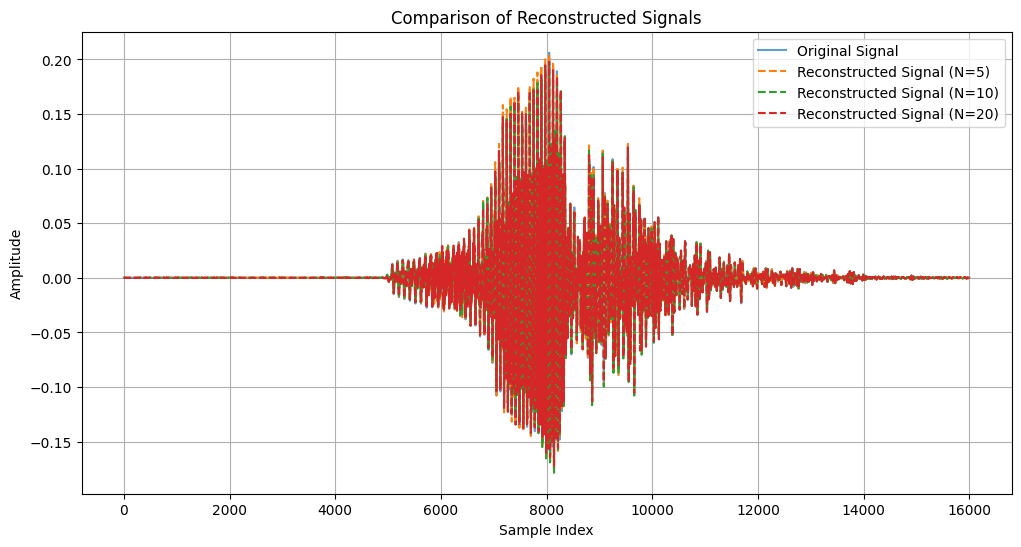

In [ ]:
plt.figure(figsize=(12, 6)) ## Compare reconstructed signals
plt.plot(x, label='Original Signal', alpha=0.7)
for N in N_values:
    plt.plot(reconstructed_signals[N], label=f'Reconstructed Signal (N={N})', linestyle='dashed')
plt.title("Comparison of Reconstructed Signals")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("\nSummary of LPC Coefficients and MSE:\n")
for N in N_values:
    print(f"N={N}:\n Coefficients: {coefficients[N]}\n MSE: {MSE_values[N]}\n")


Summary of LPC Coefficients and MSE:

N=5:
 Coefficients: [ 1.         -1.2747833   0.02351156  0.25724902 -0.06778535  0.12393362]
 MSE: 2.3122696806207264e-05

N=10:
 Coefficients: [ 1.         -1.16801351 -0.02167157  0.2526618   0.00241519  0.01455249
 -0.13885196  0.01497161  0.06297817  0.07735635  0.01743444]
 MSE: 2.060842717301354e-05

N=20:
 Coefficients: [ 1.         -1.24674064  0.2133404   0.01763214  0.11069979  0.02343625
 -0.19564357  0.04762961  0.00962045  0.18092464 -0.20324863  0.10061156
 -0.0217334  -0.12775627  0.53903842 -0.40603081  0.29573994 -0.41209714
  0.23804212 -0.05119803 -0.01763131]
 MSE: 1.5028988645095041e-05

